# Pipeline Tag Prediction

## Model A: RoBERTa-base
**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook implements an improvement model over the baseline using roBERTa-base. It runs in this order:

1. Load split dataframes used in baseline
2. Setup tokenizer
3. Setup HuggingFace Datasets
4. Setup Data and Metrics for RoBERTa model
5. Train model w/ data ablation experiments
6. Predictions and metric analysis

## 0. Setup

In [1]:
!pip install -q -U evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [2]:
import sys

In [3]:
!{sys.executable} -m pip install -q -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.5 MB/s eta 0:00:00


In [4]:
import torch
import pandas as pd
import numpy as np
import evaluate
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings, re, ast
from datasets import load_dataset, DatasetDict, Dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from transformers import RobertaTokenizer, RobertaForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

warnings.filterwarnings('ignore')

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load DataFrames

Import the train, test, and validation dataframes that were used for the baseline. They underwent an 80/20/20 split. This ensures we are using the same exact dataset across all models to best inform our model and error analysis.

In [5]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

train_df = pd.read_parquet(f'{DRIVE_DIR_2}/train_df.parquet')
val_df = pd.read_parquet(f'{DRIVE_DIR_2}/val_df.parquet')
test_df = pd.read_parquet(f'{DRIVE_DIR_2}/test_df.parquet')

metadata = json.load(open(f'{DRIVE_DIR_2}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']

Mounted at /content/drive


In [6]:
print("Shape of train:", train_df.shape)
print("Shape of validation:", val_df.shape)
print("Shape of test:", test_df.shape)

Shape of train: (116002, 7)
Shape of validation: (14501, 7)
Shape of test: (14500, 7)


## 2. Tokenizer

Setup the tokenizer for the roBERTa model. The context window for the model has a maximum length of 512 tokens. From the data exploration, most of the model cards per model have token counts that fit into the context window, but there is still a portion of cards that exceed it. For those, we simply truncate the text to the first 512 tokens rather than using a sliding window. We explore the benefits of sliding windows as a next step to model exploration, but text length is not our main error indicator based on the error analysis done in the baseline notebook.

In [7]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [8]:
# Analyze lengths of model card text to see how much truncation will affect the data

lengths = train_df["text"].str.split().str.len()
print(lengths.describe())
print("\n")
print("Row Index | Text Length")
print(lengths.sort_values(ascending=False).head(50))

count    116002.000000
mean        502.624946
std         866.689754
min           1.000000
25%         115.000000
50%         235.000000
75%         538.000000
max       14660.000000
Name: text, dtype: float64


Row Index | Text Length
85703     14660
62983     14492
85136     13924
113693    13543
99569     13541
74925     13535
68980     13533
15566     13526
48633     13521
45509     13519
115002    13518
70872     13511
47305     13481
38784     13481
78993     13481
42925     13125
34224     13073
16114     12881
213       12785
50753     12729
38109     12693
61502     12660
98076     12534
97554     12533
65086     12533
108347    12408
14098     12259
49783     12254
91989     12243
29311     12243
42596     12023
93396     11971
25088     11912
112011    11679
48325     11627
85096     11627
65902     11301
114105    11238
45446     11204
76472     11192
20877     11075
32107     11020
109143    10986
54954     10918
36815     10750
93839     10736
41616     10713
7779      1

In [9]:
for t in [500, 1000, 2000, 3000, 5000, 8000]:
    print(f">{t} words:", (lengths > t).sum())
    print(f"<{t} words:", (lengths <= t).sum())
    print()

>500 words: 31204
<500 words: 84798

>1000 words: 13784
<1000 words: 102218

>2000 words: 4804
<2000 words: 111198

>3000 words: 2414
<3000 words: 113588

>5000 words: 885
<5000 words: 115117

>8000 words: 230
<8000 words: 115772



In [10]:
# Load tokenizer from roBERTa-base

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=512, # max context window length
    )

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

## 3. Convert DataFrames into Hugging Face Dataset objects

Setup the data to be usable by the tokenizer, model, and trainer.

In [11]:
# Convert DataFrames to Hugging Face Datasets

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

In [12]:
# Tokenize each dataset (truncating to the model's max context length)

train_dataset = train_dataset.map(tokenize,
                                  batched=True,
                                  batch_size=32,
                                  remove_columns=["text"], # drop untokenized text col
                                  load_from_cache_file=False, # fresh dataset per run
                                  writer_batch_size=200 # small fix for RAM usage limits
                                  )
val_dataset = val_dataset.map(tokenize,
                              batched=True,
                              batch_size=32,
                              remove_columns=["text"],
                              load_from_cache_file=False,
                              writer_batch_size=200
                              )
test_dataset = test_dataset.map(tokenize,
                                batched=True,
                                batch_size=32,
                                remove_columns=["text"],
                                load_from_cache_file=False,
                                writer_batch_size=200
                                )

Map:   0%|          | 0/116002 [00:00<?, ? examples/s]

Map:   0%|          | 0/14501 [00:00<?, ? examples/s]

Map:   0%|          | 0/14500 [00:00<?, ? examples/s]

In [13]:
# Check dataframes got converted to same amt of dataset examples

print(f"train: {len(train_df)} docs -> {len(train_dataset)} examples")
print(f"val:   {len(val_df)} docs -> {len(val_dataset)} examples")
print(f"test:  {len(test_df)} docs -> {len(test_dataset)} examples")

train: 116002 docs -> 116002 examples
val:   14501 docs -> 14501 examples
test:  14500 docs -> 14500 examples


## 4. Prep Dataset for Model

Prepare datasets for the model and setup evaluation metrics.

In [14]:
# Setup data as PyTorch tensors for model inputs and preserves all columns

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"],
    output_all_columns=True
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"],
    output_all_columns=True
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"],
    output_all_columns=True
)

In [15]:
# Setup metrics - accuracy, macro F1, and weighted F1

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }


## 5. Train (with Data-Scaling Ablation Experiments)

Beyond training on the full dataset, we run a data-scaling ablation to understand how RoBERTa's performance varies with training set size. The model is trained separately on 25%, 50%, 75%, and 100% of the training data.


Uncomment the block below to check GPU usage while training is running.

In [16]:
# import subprocess, threading, time

# def log_gpu(interval=5, duration=60):
#     end = time.time() + duration
#     while time.time() < end:
#         out = subprocess.run(
#             ["nvidia-smi", "--query-gpu=utilization.gpu,memory.used", "--format=csv,noheader"],
#             capture_output=True, text=True
#         )
#         print(out.stdout.strip())
#         time.sleep(interval)

# threading.Thread(target=log_gpu, args=(5, 60)).start()

In [17]:
num_labels = len(label2id)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_fraction = [0.25, 0.50, 0.75, 1.00]
ablation_results = []
class_names = [id2label[str(i)] for i in range(num_labels)]

for i in train_fraction:
    print(f"\n=== Training RoBERTa-base on {int(i * 100)}% of training data ===")

    n_samples = int(len(train_dataset) * i)
    train_subset = train_dataset.shuffle(seed=42).select(range(n_samples))

    # Fresh model per run so each data-scaling point starts from the same pretrained weights
    roBERTa_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=num_labels)

    training_args = TrainingArguments(
        output_dir=f'./results_{int(i * 100)}pct',
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=2,
        num_train_epochs=1,
        weight_decay=0.01,
        load_best_model_at_end=True,
        fp16=True,
        dataloader_num_workers=2,
        dataloader_pin_memory=True,
        optim="adamw_torch_fused",
    )

    trainer = Trainer(
        model=roBERTa_model,
        args=training_args,
        train_dataset=train_subset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )

    # Run train
    trainer.train()

    # Evaluate test per data-scaling run
    test_metrics = trainer.evaluate(eval_dataset=test_dataset)

    ablation_results.append({
        "model": "RoBERTa-base",
        "train_fraction": i,
        "train_samples": n_samples,
        "accuracy": test_metrics["eval_accuracy"],
        "macro_f1": test_metrics["eval_macro_f1"],
        "weighted_f1": test_metrics["eval_weighted_f1"],
    })

    # storing per-class F1 for each run again - similar to baseline
    test_predictions = trainer.predict(test_dataset)
    preds = test_predictions.predictions.argmax(axis=-1)
    labels = test_predictions.label_ids
    per_class_f1 = f1_score(labels, preds, average=None, labels=range(num_labels))
    ablation_results[-1]["per_class_f1"] = dict(zip(class_names, per_class_f1))


=== Training RoBERTa-base on 25% of training data ===


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.306288,0.147650,0.954900,0.952102,0.955175


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.306288,0.141336,1,0.955793,0.953781,0.956028


## 6. Predictions and Metric Analysis

In [18]:
# Data-scaling ablation results (accuracy, macro F1, weighted F1 per training fraction)

ablation_df = pd.DataFrame(ablation_results)
ablation_df

,model,train_fraction,train_samples,accuracy,macro_f1,weighted_f1,per_class_f1
0,RoBERTa-base,0.25,29000,0.926690,0.915991,0.926725,{'automatic-speech-recognition': 0.95185477505...
1,RoBERTa-base,0.50,58001,0.941724,0.936014,0.941880,{'automatic-speech-recognition': 0.97339593114...
2,RoBERTa-base,0.75,87001,0.952276,0.949319,0.952521,{'automatic-speech-recognition': 0.98193244304...
3,RoBERTa-base,1.00,116002,0.955793,0.953781,0.956028,{'automatic-speech-recognition': 0.98512137823...


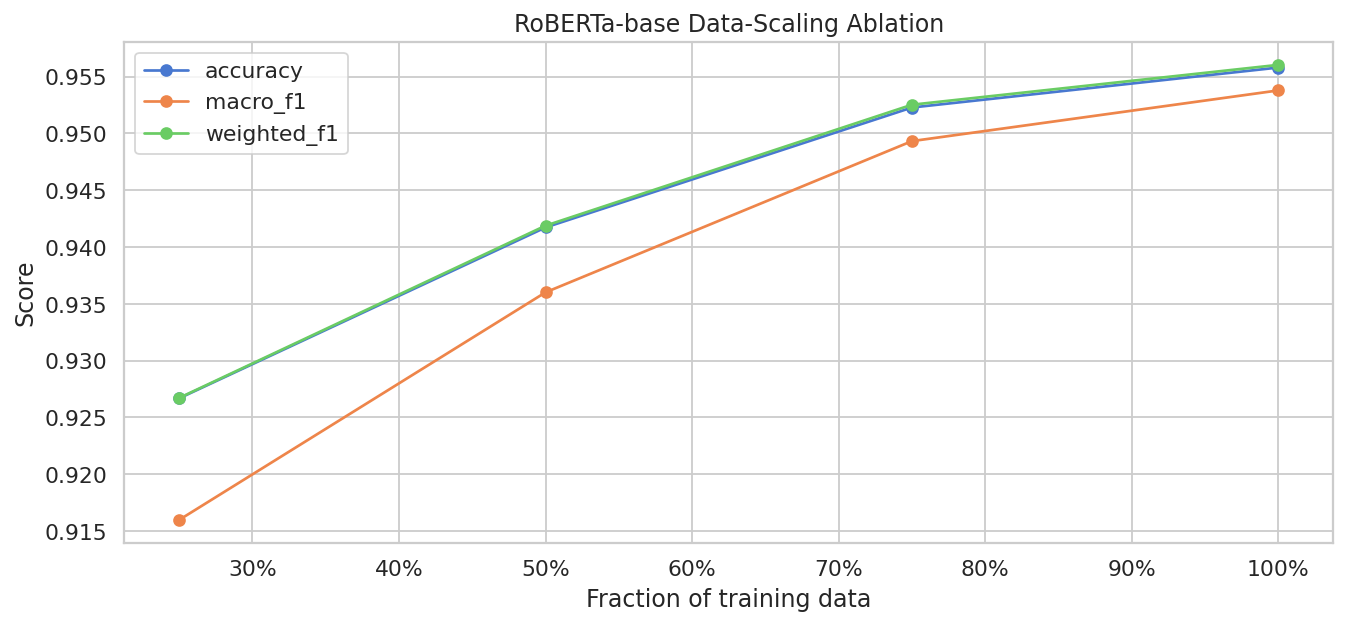

In [32]:
# Plot learning curves: metric vs. training data fraction

fig, ax = plt.subplots()
for metric_name in ["accuracy", "macro_f1", "weighted_f1"]:
    ax.plot(ablation_df["train_fraction"], ablation_df[metric_name], marker="o", label=metric_name)

ax.set_xlabel("Fraction of training data")
ax.set_ylabel("Score")
ax.set_title("RoBERTa-base Data-Scaling Ablation")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend()

fig.savefig(f'{DRIVE_DIR_2}/roberta_learning_curves.png', dpi=150, bbox_inches="tight")

plt.show()

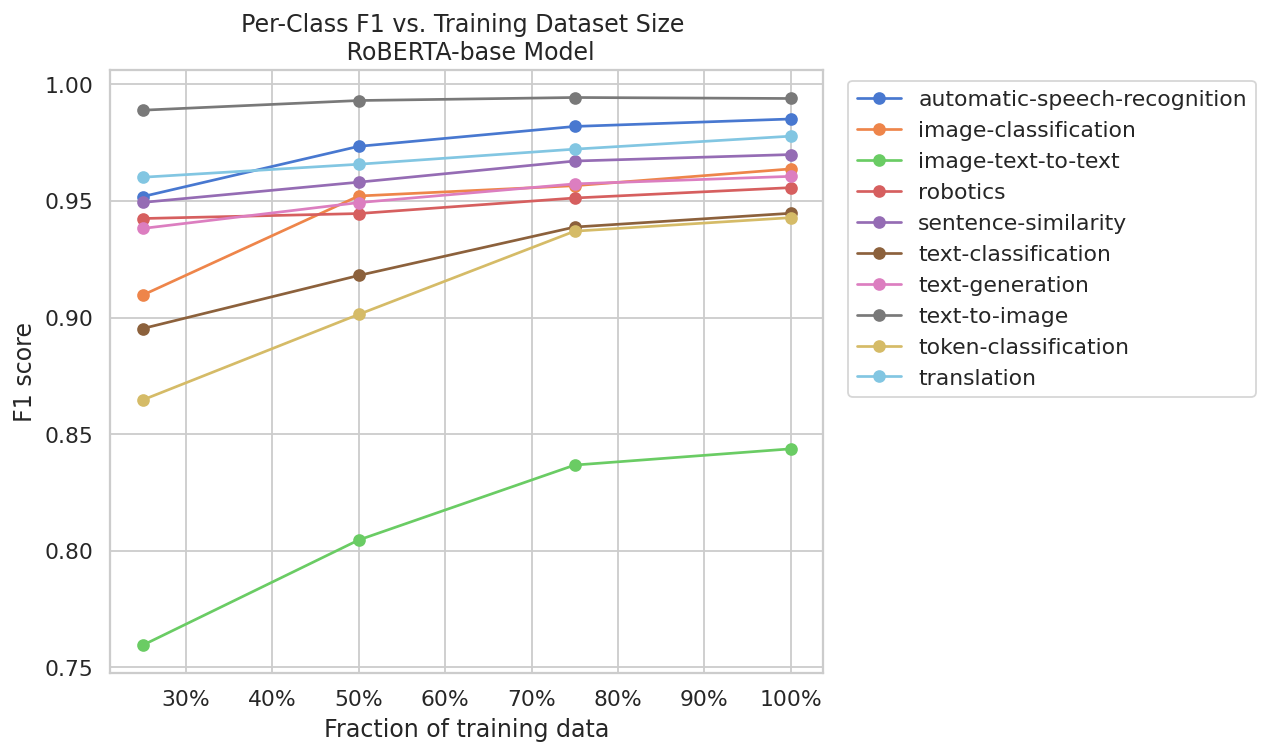

In [33]:
# Per class F1 - does it improve with more data?

per_class_df = pd.DataFrame([r["per_class_f1"] for r in ablation_results])
per_class_df["train_fraction"] = ablation_df["train_fraction"]

fig, ax = plt.subplots(figsize=(10, 6))
for class_name in class_names:
    ax.plot(per_class_df["train_fraction"], per_class_df[class_name], marker="o", label=class_name)

ax.set_xlabel("Fraction of training data")
ax.set_ylabel("F1 score")
ax.set_title("Per-Class F1 vs. Training Dataset Size \n RoBERTA-base Model")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

fig.savefig(f'{DRIVE_DIR_2}/roberta_per_class_f1.png', dpi=150, bbox_inches="tight")

plt.show()

100% of Training Data & Test Set Results:

In [21]:
test_predictions = trainer.predict(test_dataset)

In [22]:
# Get predicted class per document

preds = test_predictions.predictions.argmax(axis=1)
doc_true_labels = np.array(test_dataset["label"])

In [23]:
# Print check for final prediction counts

print(f"{len(test_df)} documents -> {len(test_dataset)} examples -> {len(preds)} predictions")

14500 documents -> 14500 examples -> 14500 predictions


In [24]:
# Classification Report

target_names = [id2label[str(i)] for i in range(len(id2label))]

print(classification_report(
    doc_true_labels,
    preds,
    target_names=target_names
))

                              precision    recall  f1-score   support

automatic-speech-recognition       0.99      0.98      0.99       639
        image-classification       0.97      0.96      0.96       347
          image-text-to-text       0.82      0.86      0.84      1288
                    robotics       0.96      0.95      0.96       421
         sentence-similarity       0.97      0.97      0.97       350
         text-classification       0.95      0.94      0.94      1095
             text-generation       0.96      0.96      0.96      6810
               text-to-image       0.99      0.99      0.99      2299
        token-classification       0.94      0.94      0.94       394
                 translation       0.98      0.97      0.98       857

                    accuracy                           0.96     14500
                   macro avg       0.96      0.95      0.95     14500
                weighted avg       0.96      0.96      0.96     14500



In [25]:
# Save the fine-tuned model and tokenizer back to Google Drive to reuse it
save_dir = f'{DRIVE_DIR_2}/roberta_pipeline_tag_model'
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Model saved to {save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/266-pipeline-tag-prediction/roberta_pipeline_tag_model


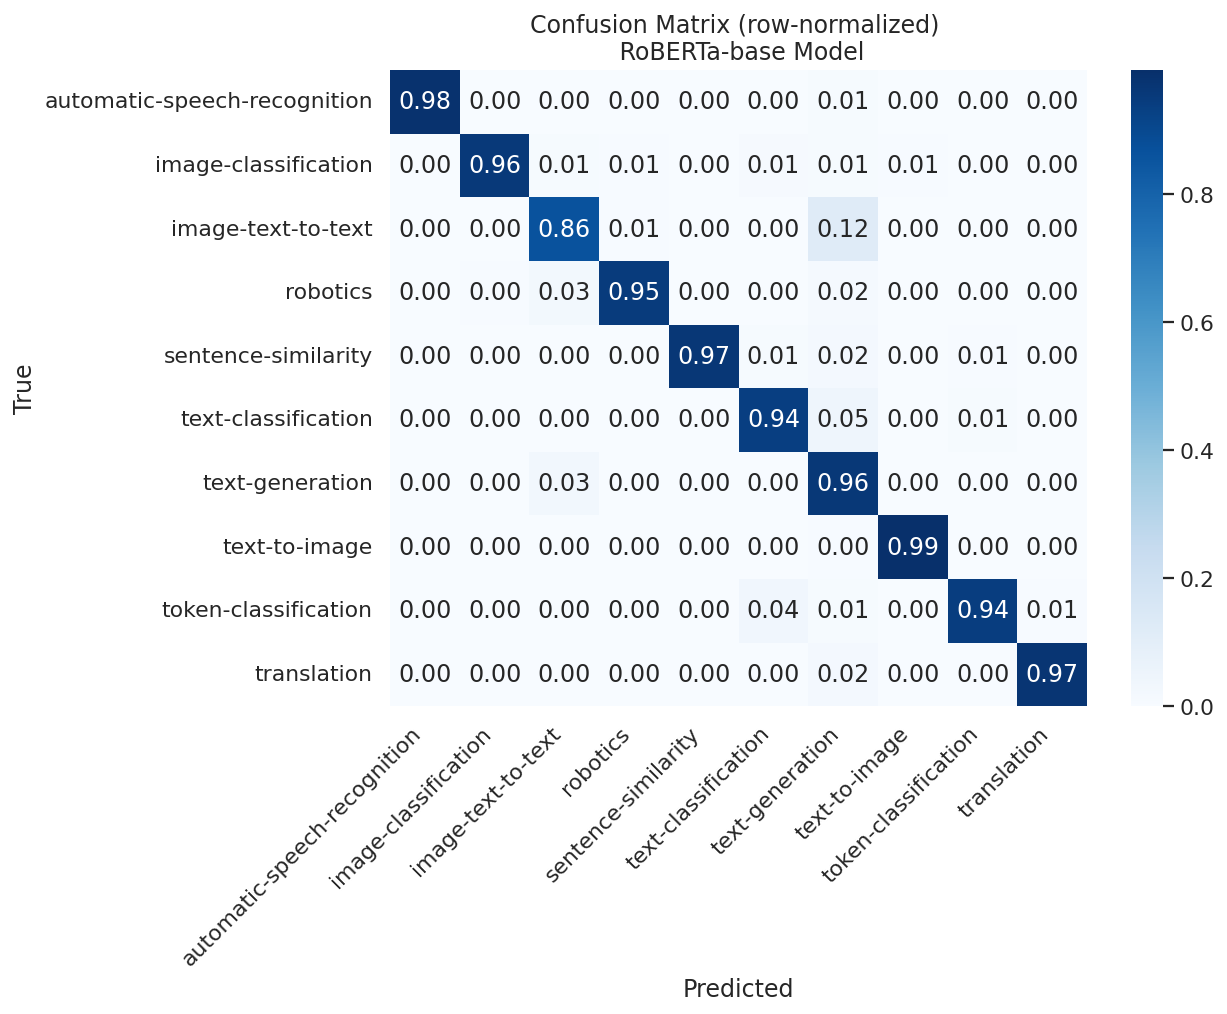

In [31]:
# Confusion Matrix - recall

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(doc_true_labels, preds, normalize="true")
labels = class_names

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (row-normalized) \n RoBERTa-base Model")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
fig.savefig(f'{DRIVE_DIR_2}/roberta_confusion_matrix.png', dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# Save all the results so don't have to re-run training loop

import json, shutil, os

# 1. Saving RoBERTa ablation results
with open(f'{DRIVE_DIR_2}/roberta_ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)
print("Saved roberta_ablation_results.json")

# Copy local checkpoint folders for each fraction to Drive
for i in [25, 50, 75, 100]:
    local_dir = f'./results_{i}pct'
    if os.path.exists(local_dir):
        checkpoints = [d for d in os.listdir(local_dir) if d.startswith('checkpoint')]
        if checkpoints:
            src = os.path.join(local_dir, checkpoints[-1])
            dst = f'{DRIVE_DIR_2}/roberta_frac_{i}pct'
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")
    else:
        print(f"No local dir found for {i}%, skipping")

# Saving test preds and classification report
import numpy as np
if 'preds' in globals() and 'doc_true_labels' in globals():
    np.save(f'{DRIVE_DIR_2}/roberta_test_preds.npy', preds)
    np.save(f'{DRIVE_DIR_2}/roberta_test_true_labels.npy', doc_true_labels)
    from sklearn.metrics import classification_report
    report_dict = classification_report(doc_true_labels, preds, target_names=target_names, output_dict=True)
    with open(f'{DRIVE_DIR_2}/roberta_classification_report.json', 'w') as f:
        json.dump(report_dict, f, indent=2)
    print("Saved RoBERTa predictions and classification report")
else:
    print("preds/doc_true_labels not in memory yet")

Saved roberta_ablation_results.json
Copied ./results_25pct/checkpoint-907 -> /content/drive/MyDrive/266-pipeline-tag-prediction/roberta_frac_25pct
Copied ./results_50pct/checkpoint-1813 -> /content/drive/MyDrive/266-pipeline-tag-prediction/roberta_frac_50pct
Copied ./results_75pct/checkpoint-2719 -> /content/drive/MyDrive/266-pipeline-tag-prediction/roberta_frac_75pct
Copied ./results_100pct/checkpoint-3626 -> /content/drive/MyDrive/266-pipeline-tag-prediction/roberta_frac_100pct
Saved RoBERTa predictions and classification report
